<a href="https://colab.research.google.com/github/10dimensions/large-notebook-repository/blob/master/A_I_World_Image_Video_Generator_Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CogVideoX-2b# Free Google Colab AI Image + Video Generation Lab

This notebook is built for **Google Colab**, not regular Python.

## What this does

- Generate images with free/open models
- Generate short videos with free/open models
- Save outputs to `/content/ai_outputs`
- Let you test prompts quickly

## Best beginner path

1. Use **SDXL-Turbo** first because it is the fastest.
2. Use **SDXL-Lightning** for better quality.
3. Use **AnimateDiff-Lightning** for short video.
4. Use **CogVideoX-2b after AnimateDiff** works (heavier)
5. Skip the advanced/heavy models unless you have a good GPU session.

## Important

Free Colab GPU access is not guaranteed. If something crashes, lower the resolution, lower video frames, or restart the runtime.

# 1. Turn on GPU

In Colab:

**Runtime → Change runtime type → Hardware accelerator → T4 GPU → Save**

Then run this cell.

In [ ]:
!nvidia-smi

Tue Jun  2 03:10:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 2. Install packages

Run this once per Colab session.

In [ ]:
!pip -q install --upgrade diffusers transformers accelerate safetensors imageio imageio-ffmpeg peft

# 3. Imports and helper functions

In [ ]:
import os
import gc
import torch
from IPython.display import display, Video
from diffusers.utils import export_to_video

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

OUTPUT_DIR = "/content/ai_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Device:", device)
print("Output folder:", OUTPUT_DIR)

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def save_and_show_image(image, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    image.save(path)
    display(image)
    print("Saved to:", path)
    return path

Device: cuda
Output folder: /content/ai_outputs


# 4. Prompting guide

## Image prompt formula

Use:

**subject + setting + composition + lighting + style + quality details**

Example:

`a rugged outdoor wedding ring on a mossy rock, macro product photography, shallow depth of field, soft morning light, premium lifestyle brand, realistic, detailed`

## Video prompt formula

Use:

**subject + action + camera movement + environment + style**

Example:

`a golden retriever running through a field of wildflowers, cinematic tracking shot, soft sunlight, gentle wind, realistic`

## Negative prompt

Use this as a default:

`blurry, low quality, distorted, deformed, text, watermark, logo`

# 5. Image option A: SDXL-Turbo

Best for fast testing. This is the easiest first demo.

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


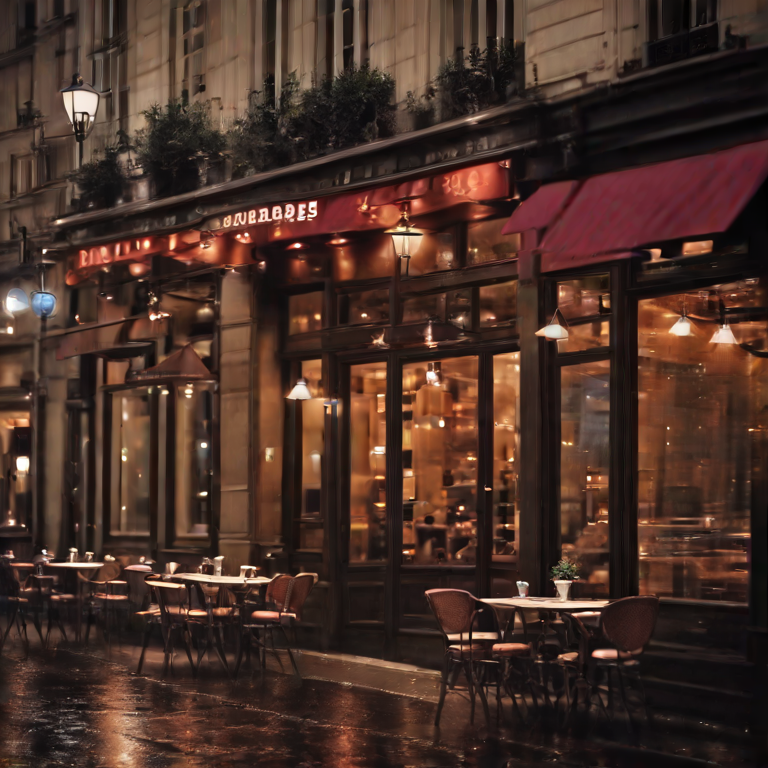

Saved to: /content/ai_outputs/sdxl_turbo_test.png


'/content/ai_outputs/sdxl_turbo_test.png'

In [ ]:
clear_memory()

from diffusers import StableDiffusionXLPipeline

pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=dtype,
    variant="fp16" if dtype == torch.float16 else None
).to(device)

pipe.enable_attention_slicing()

prompt = "a cozy Paris cafe at night, cinematic photography, warm lights, rain on the windows, realistic"
negative_prompt = "blurry, low quality, distorted, deformed, text, watermark, logo"

image = pipe(
    prompt=prompt,
    num_inference_steps=1,
    guidance_scale=0.0,
    width=768,
    height=768
).images[0]

save_and_show_image(image, "sdxl_turbo_test.png")

# 6. Image option B: SDXL-Lightning

Better quality than Turbo while still being fast.

If this fails, restart the runtime and use SDXL-Turbo.

In [ ]:
clear_memory()

from diffusers import StableDiffusionXLPipeline, EulerDiscreteScheduler, UNet2DConditionModel
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file
import torch

base_model = "stabilityai/stable-diffusion-xl-base-1.0"
repo = "ByteDance/SDXL-Lightning"
ckpt = "sdxl_lightning_4step_unet.safetensors"

# Load SDXL base UNet structure
unet = UNet2DConditionModel.from_config(
    base_model,
    subfolder="unet"
).to(device, dtype)

# Download and load the full SDXL-Lightning UNet weights
ckpt_path = hf_hub_download(
    repo_id=repo,
    filename=ckpt
)

unet.load_state_dict(
    load_file(ckpt_path, device=device)
)

# Build the SDXL pipeline using the Lightning UNet
pipe = StableDiffusionXLPipeline.from_pretrained(
    base_model,
    unet=unet,
    torch_dtype=dtype,
    variant="fp16" if dtype == torch.float16 else None
).to(device)

pipe.scheduler = EulerDiscreteScheduler.from_config(
    pipe.scheduler.config,
    timestep_spacing="trailing"
)

pipe.enable_attention_slicing()

prompt = "a rugged outdoor wedding ring on a mossy rock, macro product photography, shallow depth of field, soft morning light, premium lifestyle brand, realistic, detailed"
negative_prompt = "blurry, low quality, distorted, deformed, text, watermark, logo"

image = pipe(
    prompt=prompt,
    num_inference_steps=4,
    guidance_scale=0,
    width=1024,
    height=1024
).images[0]

save_and_show_image(image, "sdxl_lightning_test.png")

NameError: name 'clear_memory' is not defined

# 7. Short video option: AnimateDiff-Lightning

This is the best free-Colab-friendly video option.

Start small:
- 512x512
- 16 frames
- 4 steps

If it crashes, change `num_frames=16` to `num_frames=8`.

In [ ]:
clear_memory()

import torch
from diffusers import AnimateDiffPipeline, EulerDiscreteScheduler
from diffusers.utils import export_to_video
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file
from IPython.display import Video # Added this import to ensure Video() works

device = "cuda"
dtype = torch.float16

# Base video pipeline
pipe = AnimateDiffPipeline.from_pretrained(
    "emilianJR/epiCRealism",
    torch_dtype=dtype
).to(device)

# Scheduler required for AnimateDiff-Lightning
pipe.scheduler = EulerDiscreteScheduler.from_config(
    pipe.scheduler.config,
    timestep_spacing="trailing",
    beta_schedule="linear"
)

# Load the AnimateDiff-Lightning checkpoint correctly
repo = "ByteDance/AnimateDiff-Lightning"
ckpt = "animatediff_lightning_4step_diffusers.safetensors"

pipe.unet.load_state_dict(
    load_file(hf_hub_download(repo, ckpt), device=device),
    strict=False
)

pipe.enable_vae_slicing()
pipe.enable_attention_slicing()

prompt = "a white sports car driving through a neon-lit tunnel, colorful lights reflecting across the bodywork, slow cinematic tracking shot, realistic, dynamic"

negative_prompt = "blurry, low quality, distorted, deformed, bad anatomy, bad face, extra limbs, duplicate people, warped motion, flickering, shaky camera, text, watermark, logo, cartoon, anime"

output = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    guidance_scale=1.0,
    num_inference_steps=4,
    num_frames=16,
    width=512,
    height=512
)

# FIXED SECTION: Defined the video_path variable before using it
video_path = "animatediff_test.mp4"

export_to_video(output.frames[0], video_path, fps=8)
print("Saved to:", video_path)
Video(video_path, embed=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 1. Install the required compression libraries first
!pip install -q bitsandbytes accelerate

import os
import gc
import torch
from IPython.display import Video
from transformers import T5EncoderModel, AutoTokenizer, BitsAndBytesConfig
from diffusers import AutoencoderKLCogVideoX, CogVideoXTransformer3DModel, CogVideoXPipeline, CogVideoXDPMScheduler
from diffusers.utils import export_to_video

def flush_memory():
    gc.collect()
    torch.cuda.empty_cache()

flush_memory()

model_id = "THUDM/CogVideoX-2b"

print("1. Setting up 4-Bit Compression Configuration...")
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

print("2. Streaming Text Encoder directly to GPU in 4-bit (Saves System RAM)...")
text_encoder = T5EncoderModel.from_pretrained(
    model_id,
    subfolder="text_encoder",
    quantization_config=quantization_config,
    device_map="auto" # Dynamically streams chunks directly onto the GPU
)
flush_memory()

print("3. Loading Transformer directly to GPU VRAM...")
transformer = CogVideoXTransformer3DModel.from_pretrained(
    model_id,
    subfolder="transformer",
    torch_dtype=torch.float16
).to("cuda")
flush_memory()

print("4. Loading VAE directly to GPU VRAM...")
vae = AutoencoderKLCogVideoX.from_pretrained(
    model_id,
    subfolder="vae",
    torch_dtype=torch.float16
).to("cuda")
flush_memory()

print("5. Assembling Pipeline Components...")
tokenizer = AutoTokenizer.from_pretrained(model_id, subfolder="tokenizer")
scheduler = CogVideoXDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

pipe = CogVideoXPipeline(
    tokenizer=tokenizer,
    text_encoder=text_encoder,
    transformer=transformer,
    vae=vae,
    scheduler=scheduler
)

# Crucial: Since everything fits in VRAM now, do NOT use cpu_offload!
pipe.vae.enable_slicing()
pipe.vae.enable_tiling()
flush_memory()

# --- Generation Phase ---
prompt = (
    "a golden retriever running slowly through a sunny grass field, "
    "soft sunlight, simple background, realistic, natural movement"
)

print("6. Launching Generation (Safe from RAM/VRAM crashes)...")
output = pipe(
    prompt=prompt,
    height=320,
    width=576,
    num_frames=16,
    guidance_scale=6.0,
    num_inference_steps=25
).frames[0]

# Standard Colab output configuration from your original notebook
OUTPUT_DIR = "/content" # Adjust if your notebook defines OUTPUT_DIR elsewhere
video_path = os.path.join(OUTPUT_DIR, "cogvideo_quantized_success.mp4")
export_to_video(output, video_path, fps=8)

print("Saved to:", video_path)
Video(video_path, embed=True)

# 8. Download your outputs

Your files are saved here:

`/content/ai_outputs`

To download:
1. Click the folder icon on the left side of Colab.
2. Open `ai_outputs`.
3. Right-click the image or video.
4. Click **Download**.

# 9. Troubleshooting

## CUDA out of memory

Try this:

1. Run `clear_memory()`
2. Lower image size from `1024` to `768` or `512`
3. Lower video frames from `16` to `8`
4. Restart runtime
5. Use SDXL-Turbo instead of heavier models

## No GPU available

Free Colab does not always give you a GPU. Try again later.

## Video is too slow

That is normal on free Colab. Keep videos short.